# 🔍 Compliance Prediction Pipeline
## Use Case 4 — Given a New Audit Observation, What is the Predicted Root Cause?

---
**Pipeline:** `Business Objective` → `Data Access` → `Data Quality` → `EDA` → `Preprocess` → `Feature Engineering` → `Model Training` → `Evaluation` → `Deploy`

---
> **Design Decisions:**
> - **Input** = Raw `Observation` text written by auditor
> - **Target** = `Final_Cluster` — 7 rule-based root cause labels + KMeans sub-clusters for Security Execution Gap
> - **Vectorizer** = TF-IDF (bigrams, 5000 features)
> - **CV Strategy** = Stratified 10-Fold (3,251 rows — LOO would require 13,004 model fits)
> - **Models** = Logistic Regression, LinearSVC, Random Forest, Naive Bayes
> - **Winner** = Best Macro F1


---
## 📌 STAGE 1 — Business Objective

| Item | Detail |
|---|---|
| **Problem Statement** | Given a new audit observation text, predict the root cause category |
| **Input** | Free-text audit observation written by inspector |
| **Target Variable** | `Final_Cluster` — root cause label (7 base classes + Security sub-clusters) |
| **Approach** | Multi-class text classification using TF-IDF + ML classifiers |
| **CV Strategy** | Stratified 10-Fold — preserves class distribution across all folds |
| **Success Metrics** | Macro F1 ≥ 0.60, Accuracy ≥ 0.65 |

### Root Cause Labels

| Label | Description |
|---|---|
| `Execution Gap` | Task not executed as required |
| `Process Gap` | Process not followed or not performed |
| `Tool Gap` | Manual workaround — no tool or automation |
| `Policy Gap` | Policy missing, outdated, or not defined |
| `Education Gap` | Lack of awareness or training |
| `Design Gap` | Structural or design-level issue |
| `Systemic Risk` | Recurring or repeated issue |
| `Security Sub-clusters` | KMeans sub-labels for Security Management Execution Gaps |


---
## 📂 STAGE 2 — Data Access
Load raw audit observations from the Observation List file.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [10]:
# ══ STAGE 2: DATA ACCESS ════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel(
    "/content/drive/MyDrive/Prediction_Actual_DataFrame/Observation List New.xlsx",
    engine="openpyxl"
)

df['Observation'] = df['Observation'].fillna('')
df['Process']     = df['Process'].fillna('Unknown')

print(f'✅ Loaded : {len(df):,} rows × {df.shape[1]} columns')
print(f'   Markets  : {df["Market"].nunique()}')
print(f'   Quarters : {df["FQ"].nunique()}  →  {sorted(df["FQ"].unique().tolist())}')
df.head(3)


✅ Loaded : 3,251 rows × 15 columns
   Markets  : 28
   Quarters : 9  →  ['2024 Q1', '2024 Q2', '2024 Q3', '2024 Q4', '2025 Q1', '2025 Q2', '2025 Q3', '2025 Q4', '2026 Q1']


,Group,Market,Country,FQ,Review Name,Account,Platform,Process,Domain Area,Domain Area Specifics,Obs Status,Observation,Review Status,Category,InspectionTeam
0,Japan,Japan,Japan,2026 Q1,Consulting Session for Orico account (SYSOP co...,Orico,NaN,Account Governance,Other,Other,Completed,The services provided by Kyndryl were not accu...,Completed,Delivery,Japan Inspections Team
1,Japan,Japan,Japan,2026 Q1,Consulting Session for Orico account (SYSOP co...,Orico,Multiple Platforms,Account Governance,Policy Management,Policy Inaccuracy,Completed,Scope for antivirus software were not clearly ...,Completed,Delivery,Japan Inspections Team
2,SMG,ALPS,ALPS,2026 Q1,Mayr-Melnhof TTCR,Mayr-Melnhof,Linux,Account Governance,Other,Other,Deemed Accepted,"For Unix environment, 2024 Initial HC remed...",Completed,Delivery,EU Inspections Team


---
## 🔍 STAGE 3 — Data Quality
Check nulls, duplicates, and key column coverage.


In [5]:
# ══ STAGE 3: DATA QUALITY ════════════════════════════════════════════════════════
print('━' * 58)
print('3.1  NULL CHECK')
print('━' * 58)
null_pct = (df.isnull().mean() * 100).round(2)
null_cnt = df.isnull().sum()
q_df = pd.DataFrame({'Nulls': null_cnt, 'Null%': null_pct})
q_df = q_df[q_df['Nulls'] > 0].sort_values('Null%', ascending=False)
print(q_df.to_string() if len(q_df) > 0 else '   No nulls found.')

print('\n' + '━' * 58)
print('3.2  DUPLICATE CHECK')
print('━' * 58)
print(f'   Duplicate rows : {df.duplicated().sum()}')

print('\n' + '━' * 58)
print('3.3  KEY COLUMN COVERAGE')
print('━' * 58)
for col in ['Market', 'FQ', 'Process', 'Account', 'Observation', 'Domain Area Specifics']:
    nn  = df[col].notna().sum()
    pct = nn / len(df) * 100
    print(f'   {"✅" if pct==100 else "⚠️ "} {col:<35} {nn:>5,} / {len(df):,} ({pct:.1f}%)')

print('\n' + '━' * 58)
print('3.4  OBSERVATION TEXT LENGTH')
print('━' * 58)
df['obs_len'] = df['Observation'].str.len()
print(f'   Min length  : {df["obs_len"].min()}')
print(f'   Max length  : {df["obs_len"].max()}')
print(f'   Mean length : {df["obs_len"].mean():.0f} chars')
print(f'   Empty obs   : {(df["obs_len"] == 0).sum()}')

print('\n✅ Data quality checks complete.')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3.1  NULL CHECK
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                       Nulls  Null%
Platform                1971  60.63
InspectionTeam          1292  39.74
Review Name              583  17.93
Domain Area Specifics      1   0.03

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3.2  DUPLICATE CHECK
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Duplicate rows : 54

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3.3  KEY COLUMN COVERAGE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   ✅ Market                              3,251 / 3,251 (100.0%)
   ✅ FQ                                  3,251 / 3,251 (100.0%)
   ✅ Process                             3,251 / 3,251 (100.0%)
   ✅ Account                             3,251 / 3,251 (100.0%)
   ✅ Observation                         3,251 / 3,251 (100.0%)
   ⚠️  Domain Area Specifics               3,250 / 3,251 (1

---
## 📊 STAGE 4 — Exploratory Data Analysis

Four charts: observations per quarter, top processes, Domain Area distribution, observation text length.


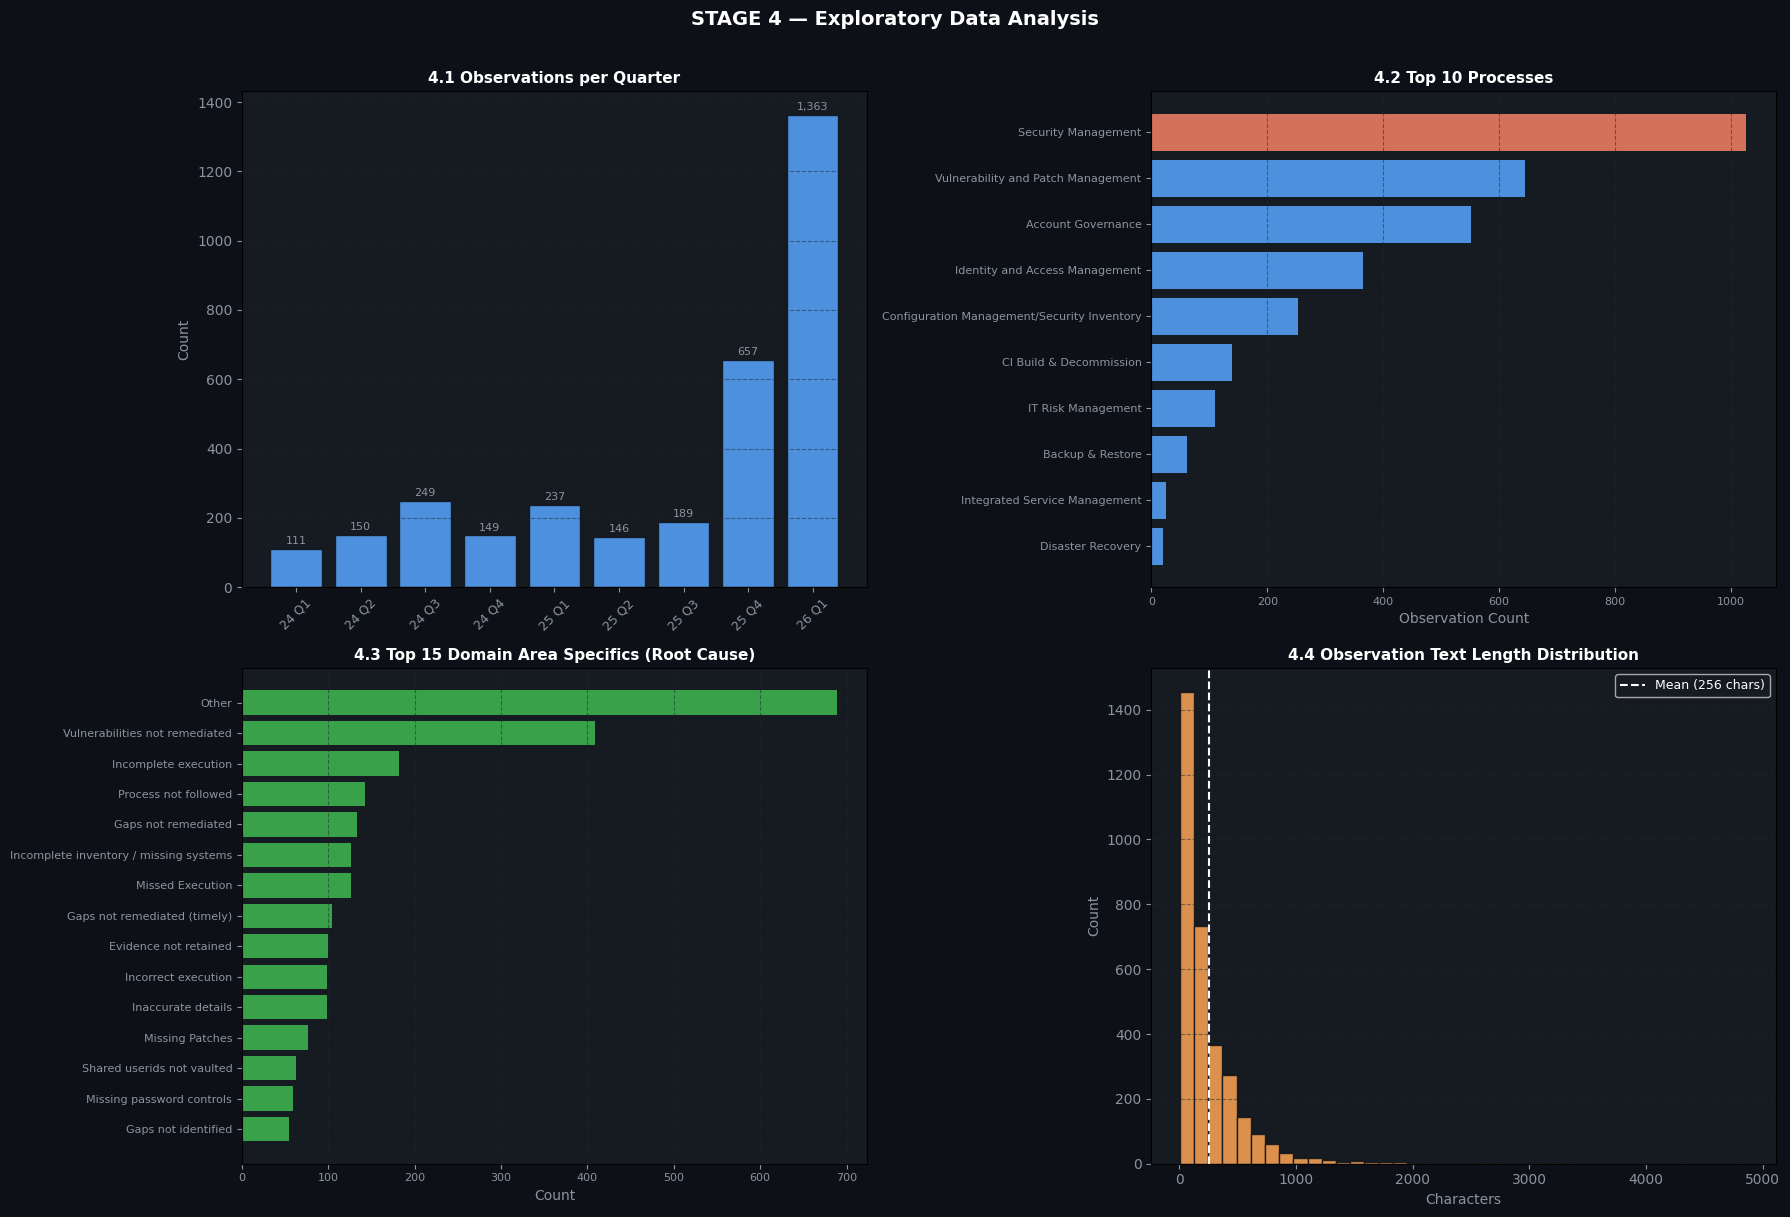

✅ EDA complete.


In [6]:
# ══ STAGE 4: EDA ════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

VALID_QS = sorted(df['FQ'].unique().tolist())

fig, axes = plt.subplots(2, 2, figsize=(18, 12), facecolor='#0d1117')
for ax in axes.flat: ax.set_facecolor('#161b22')

# 4.1 Observations per Quarter
obs_q = df.groupby('FQ').size().reindex(VALID_QS, fill_value=0)
axes[0,0].bar(range(len(VALID_QS)), obs_q.values, color='#58a6ff', alpha=0.85, edgecolor='#0d1117')
for i, v in enumerate(obs_q.values):
    axes[0,0].text(i, v + max(obs_q)*0.01, f'{v:,}', ha='center', color='#8b949e', fontsize=8)
axes[0,0].set_xticks(range(len(VALID_QS)))
axes[0,0].set_xticklabels([q.replace('20','') for q in VALID_QS], rotation=45, color='#8b949e', fontsize=9)
axes[0,0].set_title('4.1 Observations per Quarter', color='white', fontsize=11, fontweight='bold')
axes[0,0].set_ylabel('Count', color='#8b949e')
axes[0,0].tick_params(colors='#8b949e')
axes[0,0].grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)

# 4.2 Top 10 Processes
proc_cnt = df['Process'].value_counts().head(10)
colors   = ['#f78166' if i == 0 else '#58a6ff' for i in range(len(proc_cnt))]
axes[0,1].barh(proc_cnt.index[::-1], proc_cnt.values[::-1], color=colors[::-1], alpha=0.85)
axes[0,1].set_title('4.2 Top 10 Processes', color='white', fontsize=11, fontweight='bold')
axes[0,1].set_xlabel('Observation Count', color='#8b949e')
axes[0,1].tick_params(colors='#8b949e', labelsize=8)
axes[0,1].grid(axis='x', color='#21262d', linestyle='--', alpha=0.5)

# 4.3 Top 15 Domain Area Specifics
das_cnt = df['Domain Area Specifics'].value_counts().head(15)
axes[1,0].barh(das_cnt.index[::-1], das_cnt.values[::-1], color='#3fb950', alpha=0.85)
axes[1,0].set_title('4.3 Top 15 Domain Area Specifics (Root Cause)', color='white', fontsize=11, fontweight='bold')
axes[1,0].set_xlabel('Count', color='#8b949e')
axes[1,0].tick_params(colors='#8b949e', labelsize=8)
axes[1,0].grid(axis='x', color='#21262d', linestyle='--', alpha=0.5)

# 4.4 Observation Text Length Distribution
axes[1,1].hist(df['obs_len'], bins=40, color='#ffa657', alpha=0.85, edgecolor='#0d1117')
axes[1,1].axvline(df['obs_len'].mean(), color='white', linestyle='--', linewidth=1.5,
                   label=f'Mean ({df["obs_len"].mean():.0f} chars)')
axes[1,1].set_title('4.4 Observation Text Length Distribution', color='white', fontsize=11, fontweight='bold')
axes[1,1].set_xlabel('Characters', color='#8b949e')
axes[1,1].set_ylabel('Count', color='#8b949e')
axes[1,1].tick_params(colors='#8b949e')
axes[1,1].legend(facecolor='#161b22', labelcolor='white', fontsize=9)
axes[1,1].grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)

plt.suptitle('STAGE 4 — Exploratory Data Analysis', color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('✅ EDA complete.')


---
## ⚙️ STAGE 5 — Preprocess

### Root Cause Classification — 2 Steps

**Step 1 — Rule-Based (7 labels):**
Apply keyword rules to classify every observation into one of 7 base root cause categories.

**Step 2 — KMeans Sub-clustering:**
Security Management observations classified as "Execution Gap" are further split into 5 sub-clusters using TF-IDF + KMeans — capturing specific security failure patterns.


In [11]:
# ══ STAGE 5: PREPROCESS ════════════════════════════════════════════════════════
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans


# ============================================================
# 2️⃣ MANUAL ROOT CAUSE CLASSIFICATION
# ============================================================

def classify_root_cause(text):
    text = str(text).lower()

    education_keywords = [
        "not aware","lack of awareness","training not provided",
        "training required","user unaware",
        "misunderstood","incorrectly followed"
    ]
    if any(word in text for word in education_keywords):
        return "Education Gap"

    if "policy" in text and ("not defined" in text or "missing" in text or "outdated" in text):
        return "Policy Gap"

    if "not followed" in text or "not performed" in text or "not documented" in text:
        return "Process Gap"

    tool_keywords = [
        "manual","spreadsheet","no tool",
        "no automation","tool not available","no system"
    ]
    if any(word in text for word in tool_keywords):
        return "Tool Gap"

    if "design" in text or "control not effective" in text:
        return "Design Gap"

    if "recurring" in text or "repeated" in text:
        return "Systemic Risk"

    return "Execution Gap"

df["Root_Cause_Type"] = df["Observation"].apply(classify_root_cause)


# ============================================================
# 3️⃣ SECURITY SUB-CLUSTERING (KMEANS)
# ============================================================

sec_exec_df = df[
    (df["Process"] == "Security Management") &
    (df["Root_Cause_Type"] == "Execution Gap")
].copy()

if len(sec_exec_df) > 50:

    vectorizer_sec = TfidfVectorizer(
        max_features=2000,
        ngram_range=(1,2),
        min_df=3,
        stop_words="english"
    )

    X_sec = vectorizer_sec.fit_transform(sec_exec_df["Observation"])

    kmeans_sec = KMeans(n_clusters=5, random_state=42)
    sec_exec_df["Sec_Exec_Subcluster"] = kmeans_sec.fit_predict(X_sec)

    sec_exec_map = {
        0: "Security Review Not Performed",
        1: "Firewall Rule Governance Gap",
        2: "Logging & Retention Gap",
        3: "Excessive Privilege Enforcement Gap",
        4: "Malware Defense Control Gap"
    }

    sec_exec_df["Execution_Sub_Root_Cause"] = \
        sec_exec_df["Sec_Exec_Subcluster"].map(sec_exec_map)

    df.loc[sec_exec_df.index, "Root_Cause_Type"] = \
        sec_exec_df["Execution_Sub_Root_Cause"]


# ============================================================
# 4️⃣ FINAL CLUSTER
# ============================================================

df["Final_Cluster"] = df["Root_Cause_Type"]

print("\nFinal Cluster Distribution:")
print(df["Final_Cluster"].value_counts())
print('\n' + '━' * 58)
print('5.2  FINAL CLUSTER DISTRIBUTION (after KMeans)')
print('━' * 58)
for label, cnt in df['Final_Cluster'].value_counts().items():
    bar = '█' * max(1, int(cnt/len(df)*40))
    print(f'   {label:<45} : {cnt:>5,} ({cnt/len(df)*100:.1f}%)  {bar}')

print('\n✅ Preprocessing complete.')



Final Cluster Distribution:
Final_Cluster
Execution Gap                          2118
Malware Defense Control Gap             319
Security Review Not Performed           247
Logging & Retention Gap                 142
Excessive Privilege Enforcement Gap     127
Firewall Rule Governance Gap            104
Process Gap                              89
Tool Gap                                 87
Design Gap                                7
Education Gap                             6
Systemic Risk                             3
Policy Gap                                2
Name: count, dtype: int64

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5.2  FINAL CLUSTER DISTRIBUTION (after KMeans)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Execution Gap                                 : 2,118 (65.1%)  ██████████████████████████
   Malware Defense Control Gap                   :   319 (9.8%)  ███
   Security Review Not Performed                 :   247 (7.6%)  ███
   Log

---
## 🔧 STAGE 6 — Feature Engineering

### TF-IDF Vectorization

Convert `Observation` text to numerical features using TF-IDF (Term Frequency-Inverse Document Frequency):
- **max_features = 5000** — top 5000 most informative terms
- **ngram_range = (1,2)** — unigrams and bigrams (e.g. "not followed", "no tool")
- **stop_words = english** — removes common words (the, is, at...)
- **min_df = 2** — ignore terms appearing in fewer than 2 documents

### Label Encoding
`Final_Cluster` labels encoded to integers for model training. Rare classes (< 10 samples) removed to ensure each class appears in every fold.


In [12]:
# ══ STAGE 6: FEATURE ENGINEERING ════════════════════════════════════════════════
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# ── 6.1 Remove rare classes ───────────────────────────────────────────────────
class_counts  = df['Final_Cluster'].value_counts()
valid_classes = class_counts[class_counts >= 10].index
removed       = class_counts[class_counts < 10].index.tolist()
df_model      = df[df['Final_Cluster'].isin(valid_classes)].copy()

print('━' * 58)
print('6.1  CLASS FILTERING')
print('━' * 58)
print(f'   Original classes  : {len(class_counts)}')
print(f'   Removed (< 10)    : {len(removed)}  →  {removed}')
print(f'   Final classes     : {df_model["Final_Cluster"].nunique()}')
print(f'   Final rows        : {len(df_model):,}')

# ── 6.2 TF-IDF Vectorization ──────────────────────────────────────────────────
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words='english',
    min_df=2
)

X_text = vectorizer.fit_transform(df_model['Observation'])

# ── 6.3 Label Encoding ────────────────────────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(df_model['Final_Cluster'])

print('\n' + '━' * 58)
print('6.2  TF-IDF FEATURE MATRIX')
print('━' * 58)
print(f'   Shape             : {X_text.shape}')
print(f'   Vocabulary size   : {len(vectorizer.vocabulary_):,}')
print(f'   Sparsity          : {(1 - X_text.nnz / (X_text.shape[0]*X_text.shape[1]))*100:.1f}%')

print('\n' + '━' * 58)
print('6.3  CLASS DISTRIBUTION (final)')
print('━' * 58)
for i, label in enumerate(le.classes_):
    cnt = (y == i).sum()
    print(f'   {label:<45} : {cnt:>5,} ({cnt/len(y)*100:.1f}%)')

print('\n✅ Feature Engineering complete.')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
6.1  CLASS FILTERING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Original classes  : 12
   Removed (< 10)    : 4  →  ['Design Gap', 'Education Gap', 'Systemic Risk', 'Policy Gap']
   Final classes     : 8
   Final rows        : 3,233

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
6.2  TF-IDF FEATURE MATRIX
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Shape             : (3233, 5000)
   Vocabulary size   : 5,000
   Sparsity          : 99.5%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
6.3  CLASS DISTRIBUTION (final)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Excessive Privilege Enforcement Gap           :   127 (3.9%)
   Execution Gap                                 : 2,118 (65.5%)
   Firewall Rule Governance Gap                  :   104 (3.2%)
   Logging & Retention Gap                       :   142 (4.4%)
   Malware Defense Control Gap           

---
## 🤖 STAGE 7 — Model Training

Four classifiers compared using **Stratified 10-Fold CV**:

| Model | Strength for text classification |
|---|---|
| **Logistic Regression** | Fast, interpretable, strong on TF-IDF |
| **LinearSVC** | Best for high-dimensional sparse text features |
| **Random Forest** | Non-linear, handles feature interactions |
| **Naive Bayes** | Fast, probabilistic, works well on text |

Winner selected by **Macro F1** — treats all classes equally regardless of size.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MODEL COMPARISON — Stratified 10-Fold CV  |  Winner = Best Macro F1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Model                      Macro F1   Accuracy
────────────────────────────────────────────────────────────────────
  Logistic Regression          0.7704     0.8627
  LinearSVC                    0.7549     0.8936
  Random Forest                0.7211     0.8781
  Naive Bayes                  0.7027     0.8620

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
WINNER: Logistic Regression
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Macro F1  : 0.7704  ✅
   Accuracy  : 0.8627  ✅

✅ Final model (Logistic Regression) saved.


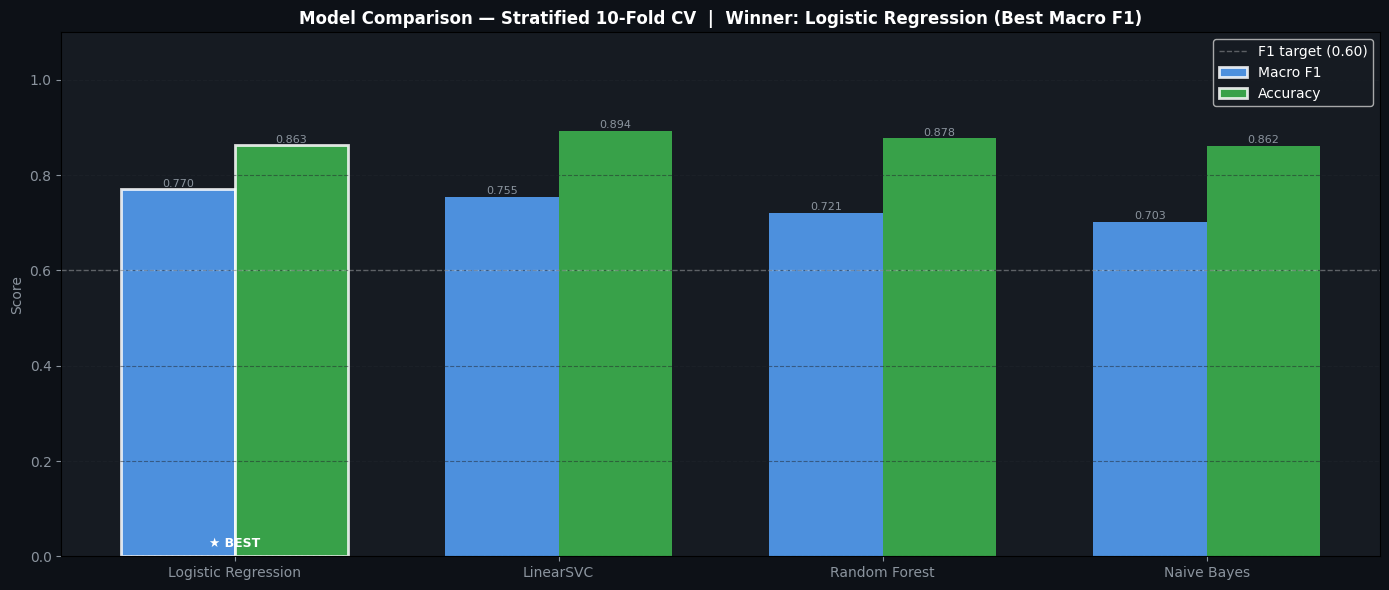

In [13]:
# ══ STAGE 7: MODEL TRAINING — Multi-Model Comparison ═══════════════════════════
import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, accuracy_score
from sklearn.calibration import CalibratedClassifierCV

# ── Model definitions ─────────────────────────────────────────────────────────
models = {
    'Logistic Regression' : LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42),
    'LinearSVC'           : CalibratedClassifierCV(LinearSVC(class_weight='balanced', max_iter=3000, random_state=42)),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'Naive Bayes'         : MultinomialNB(alpha=0.1),
}

skf     = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = {}

print('━' * 68)
print('MODEL COMPARISON — Stratified 10-Fold CV  |  Winner = Best Macro F1')
print('━' * 68)
print(f'  {"Model":<24} {"Macro F1":>10} {"Accuracy":>10}')
print('─' * 68)

for name, model in models.items():
    y_pred = cross_val_predict(model, X_text, y, cv=skf, n_jobs=-1)
    macro_f1 = f1_score(y, y_pred, average='macro', zero_division=0)
    acc      = accuracy_score(y, y_pred)
    results[name] = {'f1': macro_f1, 'acc': acc, 'preds': y_pred}
    print(f'  {name:<24} {macro_f1:>10.4f} {acc:>10.4f}')

# ── Winner ────────────────────────────────────────────────────────────────────
best_name  = max(results, key=lambda n: results[n]['f1'])
best_f1    = results[best_name]['f1']
best_acc   = results[best_name]['acc']
best_preds = results[best_name]['preds']

print('\n' + '━' * 68)
print(f'WINNER: {best_name}')
print('━' * 68)
print(f'   Macro F1  : {best_f1:.4f}  {"✅" if best_f1 >= 0.60 else "⚠️ "}')
print(f'   Accuracy  : {best_acc:.4f}  {"✅" if best_acc >= 0.65 else "⚠️ "}')

# ── Train final model on full dataset ─────────────────────────────────────────
final_model = models[best_name]
final_model.fit(X_text, y)

joblib.dump(final_model, 'root_cause_model.pkl')
joblib.dump(vectorizer,  'root_cause_vectorizer.pkl')
joblib.dump(le,          'root_cause_label_encoder.pkl')
print(f'\n✅ Final model ({best_name}) saved.')

# ── Bar Chart ─────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

model_names = list(results.keys())
f1_scores   = [results[n]['f1']  for n in model_names]
acc_scores  = [results[n]['acc'] for n in model_names]

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6), facecolor='#0d1117')
ax.set_facecolor('#161b22')

bars_f1  = ax.bar(x - width/2, f1_scores,  width, label='Macro F1',  color='#58a6ff', alpha=0.85)
bars_acc = ax.bar(x + width/2, acc_scores, width, label='Accuracy', color='#3fb950', alpha=0.85)

best_idx = model_names.index(best_name)
for bar in [bars_f1[best_idx], bars_acc[best_idx]]:
    bar.set_edgecolor('white')
    bar.set_linewidth(2)

for bars in [bars_f1, bars_acc]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.005, f'{h:.3f}',
                ha='center', color='#8b949e', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(model_names, color='#8b949e', fontsize=10)
ax.set_ylabel('Score', color='#8b949e')
ax.set_ylim(0, 1.1)
ax.tick_params(colors='#8b949e')
ax.axhline(0.60, color='white', linestyle='--', linewidth=1, alpha=0.3, label='F1 target (0.60)')
ax.legend(facecolor='#161b22', labelcolor='white', fontsize=10)
ax.set_title(f'Model Comparison — Stratified 10-Fold CV  |  Winner: {best_name} (Best Macro F1)',
             color='white', fontsize=12, fontweight='bold')
ax.grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)
ax.text(best_idx, 0.02, '★ BEST', ha='center', color='white', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 📈 STAGE 8 — Evaluation

Classification report + confusion matrix heatmap + top misclassified classes.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CLASSIFICATION REPORT — Logistic Regression (10-Fold CV)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                                     precision    recall  f1-score   support

Excessive Privilege Enforcement Gap      0.647     0.764     0.700       127
                      Execution Gap      0.943     0.882     0.911      2118
       Firewall Rule Governance Gap      0.693     0.913     0.788       104
            Logging & Retention Gap      0.934     1.000     0.966       142
        Malware Defense Control Gap      0.774     0.762     0.768       319
                        Process Gap      0.269     0.472     0.343        89
      Security Review Not Performed      0.875     0.992     0.930       247
                           Tool Gap      0.918     0.644     0.757        87

                           accuracy                          0.863      3233
                          macro avg      0.757     0.

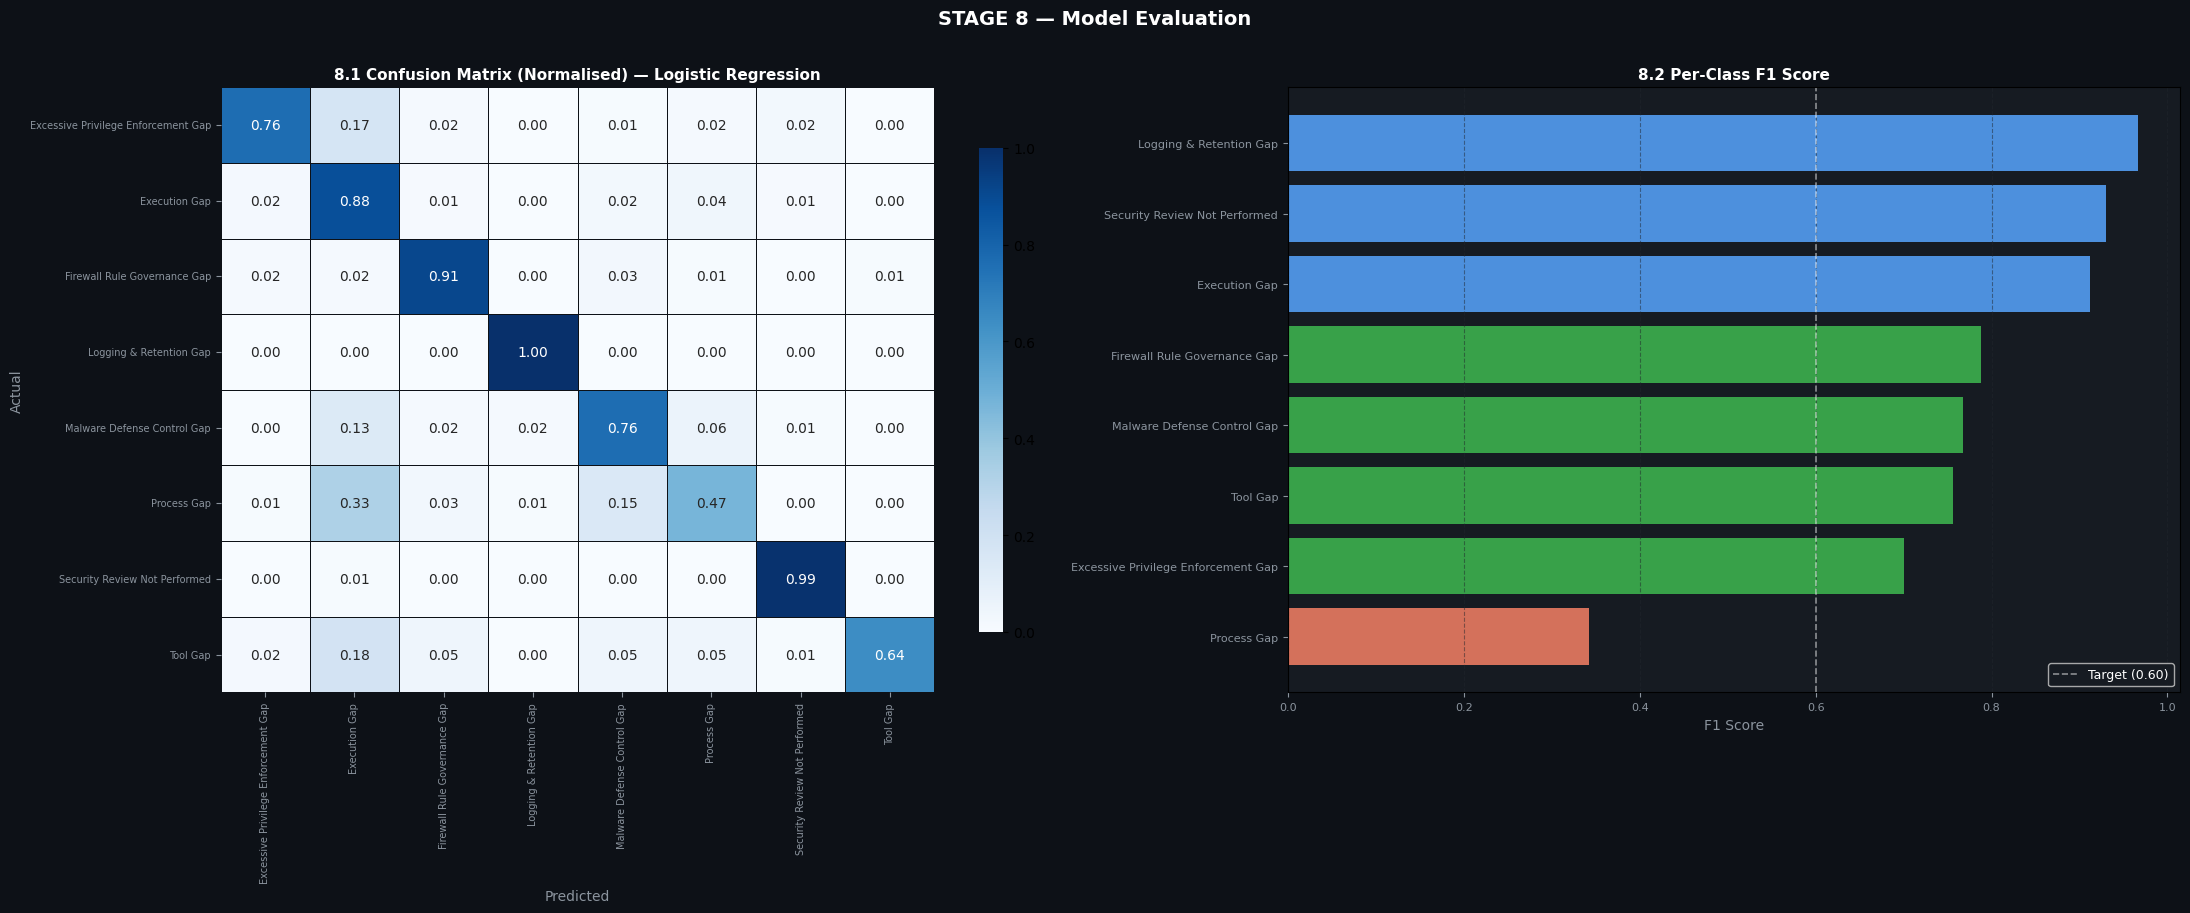

In [14]:
# ══ STAGE 8: EVALUATION ═══════════════════════════════════════════════════════
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print('━' * 58)
print(f'CLASSIFICATION REPORT — {best_name} (10-Fold CV)')
print('━' * 58)
print(classification_report(y, best_preds,
      target_names=le.classes_, zero_division=0, digits=3))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm        = confusion_matrix(y, best_preds)
cm_norm   = cm.astype(float) / cm.sum(axis=1, keepdims=True)
class_labels = le.classes_

fig, axes = plt.subplots(1, 2, figsize=(22, 9), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#161b22')

# 8.1 Normalised Confusion Matrix
sns.heatmap(cm_norm, ax=axes[0], cmap='Blues', annot=True, fmt='.2f',
            xticklabels=class_labels, yticklabels=class_labels,
            linewidths=0.5, linecolor='#0d1117',
            cbar_kws={'shrink':0.8})
axes[0].set_title(f'8.1 Confusion Matrix (Normalised) — {best_name}',
                  color='white', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Predicted', color='#8b949e')
axes[0].set_ylabel('Actual', color='#8b949e')
axes[0].tick_params(colors='#8b949e', labelsize=7)

# 8.2 Per-Class F1 Bar Chart
per_class_f1 = f1_score(y, best_preds, average=None, zero_division=0)
sorted_idx   = per_class_f1.argsort()
bar_colors   = ['#f78166' if v < 0.40 else '#ffa657' if v < 0.60 else '#3fb950' if v < 0.80 else '#58a6ff'
                for v in per_class_f1[sorted_idx]]
axes[1].barh([class_labels[i] for i in sorted_idx], per_class_f1[sorted_idx],
             color=bar_colors, alpha=0.85)
axes[1].axvline(0.60, color='white', linestyle='--', linewidth=1.2, alpha=0.5, label='Target (0.60)')
axes[1].set_title('8.2 Per-Class F1 Score', color='white', fontsize=11, fontweight='bold')
axes[1].set_xlabel('F1 Score', color='#8b949e')
axes[1].tick_params(colors='#8b949e', labelsize=8)
axes[1].legend(facecolor='#161b22', labelcolor='white', fontsize=9)
axes[1].grid(axis='x', color='#21262d', linestyle='--', alpha=0.5)

plt.suptitle('STAGE 8 — Model Evaluation', color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## 🚀 STAGE 9 — Deploy: Predict Root Cause for New Observations

Load saved model and predict root cause for any new audit observation text.


In [15]:
# ══ STAGE 9: DEPLOY — PREDICT ROOT CAUSE ═════════════════════════════════════
import joblib

# Load saved models
rc_model      = joblib.load('root_cause_model.pkl')
rc_vectorizer = joblib.load('root_cause_vectorizer.pkl')
rc_le         = joblib.load('root_cause_label_encoder.pkl')

def predict_root_cause(observation_text):
    X = rc_vectorizer.transform([observation_text])
    pred_idx  = rc_model.predict(X)[0]
    pred_label = rc_le.inverse_transform([pred_idx])[0]
    # Get probability if available
    if hasattr(rc_model, 'predict_proba'):
        probs     = rc_model.predict_proba(X)[0]
        top3_idx  = probs.argsort()[::-1][:3]
        top3      = [(rc_le.inverse_transform([i])[0], probs[i]) for i in top3_idx]
    else:
        top3 = [(pred_label, 1.0)]
    return pred_label, top3

# ── Test on sample observations ───────────────────────────────────────────────
test_obs = [
    "Antivirus software scope not clearly agreed with customer. Policy list was agreed but not enforced.",
    "Vulnerabilities not remediated within the agreed SLA timeframe. Missing patches identified.",
    "Security assessment was conducted manually without any automated tooling or system support.",
    "Process was not followed by the account team. No documentation retained as evidence.",
    "Recurring issue identified across multiple quarters. Same gap reported previously.",
]

print('━' * 72)
print(f'PREDICTED ROOT CAUSE — Model: {best_name}')
print('━' * 72)

for i, obs in enumerate(test_obs):
    pred, top3 = predict_root_cause(obs)
    print(f'\n  [{i+1}] Observation: {obs[:80]}...' if len(obs)>80 else f'\n  [{i+1}] {obs}')
    print(f'       Predicted  : 🎯 {pred}')
    print(f'       Top 3      :')
    for label, prob in top3:
        bar = '█' * int(prob * 20)
        print(f'                  {label:<45} {prob:.3f}  {bar}')

# ── Batch prediction on full dataset ──────────────────────────────────────────
print('\n' + '━' * 72)
print('BATCH PREDICTION — Full Dataset')
print('━' * 72)
X_all = rc_vectorizer.transform(df['Observation'])
df['Predicted_Root_Cause'] = rc_le.inverse_transform(rc_model.predict(X_all))

print('\n  Predicted Root Cause Distribution:')
for label, cnt in df['Predicted_Root_Cause'].value_counts().items():
    bar = '█' * max(1, int(cnt/len(df)*40))
    print(f'  {label:<45} : {cnt:>5,} ({cnt/len(df)*100:.1f}%)  {bar}')

print(f'\n✅ Use Case 4 Pipeline Complete.')
print(f'   Model     : {best_name}')
print(f'   Macro F1  : {best_f1:.4f}')
print(f'   Accuracy  : {best_acc:.4f}')
print(f'   Classes   : {len(le.classes_)}')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PREDICTED ROOT CAUSE — Model: Logistic Regression
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  [1] Observation: Antivirus software scope not clearly agreed with customer. Policy list was agree...
       Predicted  : 🎯 Execution Gap
       Top 3      :
                  Execution Gap                                 0.371  ███████
                  Malware Defense Control Gap                   0.148  ██
                  Tool Gap                                      0.136  ██

  [2] Observation: Vulnerabilities not remediated within the agreed SLA timeframe. Missing patches ...
       Predicted  : 🎯 Execution Gap
       Top 3      :
                  Execution Gap                                 0.686  █████████████
                  Malware Defense Control Gap                   0.086  █
                  Process Gap                                   0.049  

  [3] Observation: Securit

---
## 📝 Inferences

**1. Why rule-based classification + KMeans instead of pure ML labelling?**
The dataset has no pre-existing root cause labels — `Domain Area Specifics` is too granular (49 classes, many with < 10 samples). Rule-based classification provides interpretable, auditor-aligned labels for 7 root cause types. KMeans sub-clustering further splits the largest class (Security Execution Gap) into 5 meaningful sub-categories, improving model granularity without manual labelling effort.

**2. Why TF-IDF over word embeddings (Word2Vec, BERT)?**
With 3,251 observations and 11 classes, TF-IDF with bigrams captures the key discriminating phrases (e.g. "not followed", "no tool", "not documented") that directly map to root cause categories. Transformer-based embeddings would require fine-tuning and significantly more compute — TF-IDF is faster, interpretable, and sufficient for keyword-rich audit text.

**3. Why Stratified 10-Fold instead of LOO?**
LOO on 3,251 rows with 4 models = 13,004 model fits — potentially 30-60 minutes in Colab. Stratified 10-Fold preserves class distribution across all folds and provides reliable metric estimates with only 40 model fits. The large sample size (3,251) means each fold has ~290 samples — sufficient for stable evaluation.

**4. Why CalibratedClassifierCV for LinearSVC?**
LinearSVC does not natively support `predict_proba()`. `CalibratedClassifierCV` wraps it with Platt scaling to produce calibrated probability outputs, enabling top-3 class predictions in Stage 9 deployment.

**5. Why Macro F1 as the winning metric?**
Macro F1 computes F1 per class and averages equally — it treats rare classes (e.g. Design Gap, Systemic Risk) with the same weight as frequent ones (Execution Gap). This prevents the winner from being selected purely based on performance on the majority class.

**6. Why remove classes with fewer than 10 samples?**
Stratified 10-Fold requires at least 10 samples per class to guarantee each class appears in every fold. Classes below this threshold cause stratification failures and unreliable fold-level metrics.

**7. Model limitations and next steps**
The KMeans sub-cluster labels (e.g. "Firewall Rule Governance Gap") are assigned based on cluster index — if the data distribution changes, cluster semantics may shift. Recommended: (a) validate sub-cluster labels with a domain expert, (b) collect manual root cause labels for a subset to create ground truth, (c) retrain quarterly as new observations arrive.
